<a href="https://colab.research.google.com/github/faizanahmed-ai/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faizanahmed-ai/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** For an editor with limited review capacity, can a leakage-aware model rank pages in the observed declining-trend category more effectively than a transparent stale-and-visible rule?

**Decision supported:** which existing pages should be manually investigated first.

**Who acts:** a content editor or SEO lead.

**Cost of a wrong call:** a false positive wastes editorial time; a false negative may delay investigation of a visible page. The model is therefore evaluated at the top of the queue with Precision@50, not only with general classification metrics.


In [1]:
from pathlib import Path
import os, urllib.request
DATA_NAME = "content_refresh_anonymized.csv"
HERE = Path.cwd().resolve()
data_path = next((p / "data" / "raw" / DATA_NAME for p in [HERE, *HERE.parents] if (p / "data" / "raw" / DATA_NAME).exists()), None)
if data_path is None:
    ROOT = HERE / "flyrank_notebook_workspace"
    data_path = ROOT / "data" / "raw" / DATA_NAME
    data_path.parent.mkdir(parents=True, exist_ok=True)
    if not data_path.exists():
        try:
            urllib.request.urlretrieve("https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv", data_path)
        except Exception as exc:
            raise FileNotFoundError("Extract the internship ZIP and open this notebook from it, or provide the public starter CSV.") from exc
else:
    ROOT = data_path.parents[2]
os.chdir(ROOT)
OUT = ROOT / "work" / "outputs"; OUT.mkdir(parents=True, exist_ok=True)
FIG = ROOT / "work" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
print("Dataset:", data_path)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv(data_path)
df["is_declining_label"] = df["trend_direction"].astype(str).str.lower().eq("down").astype(int)
for raw in ["impressions_90d", "clicks_90d", "sessions_90d"]:
    df[f"log_{raw}"] = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))

numeric = [c for c in ["log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "days_with_impressions", "days_with_sessions", "content_age_days", "days_since_last_update", "avg_position", "ctr", "engagement_rate", "scroll_rate", "word_count", "char_count"] if c in df]
categorical = [c for c in ["content_type", "main_intent", "freshness_tier", "position_tier"] if c in df]
X, y, groups = df[numeric + categorical], df["is_declining_label"], df["client_id"].astype(str)
train_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42).split(X, y, groups=groups))

preprocess = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical),
])
def p_at_k(y_true, scores, k):
    return float(np.asarray(y_true)[np.argsort(-np.asarray(scores))[:k]].mean())

models = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=25, class_weight="balanced_subsample", random_state=42, n_jobs=-1),
}
fitted, rows = {}, []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", estimator)]).fit(X.iloc[train_idx], y.iloc[train_idx])
    scores = pipe.predict_proba(X.iloc[test_idx])[:, 1]
    fitted[name] = (pipe, scores)
    rows.append({"model":name, "roc_auc":roc_auc_score(y.iloc[test_idx], scores), "average_precision":average_precision_score(y.iloc[test_idx], scores), "precision_at_20":p_at_k(y.iloc[test_idx], scores, 20), "precision_at_50":p_at_k(y.iloc[test_idx], scores, 50)})

baseline_score = ((df["days_since_last_update"] >= 180) & (df["impressions_90d"] >= 500)).astype(float) * np.log1p(df["impressions_90d"].clip(lower=0))
rows.insert(0, {"model":"transparent_stale_visible_baseline", "roc_auc":roc_auc_score(y.iloc[test_idx], baseline_score.iloc[test_idx]), "average_precision":average_precision_score(y.iloc[test_idx], baseline_score.iloc[test_idx]), "precision_at_20":p_at_k(y.iloc[test_idx], baseline_score.iloc[test_idx], 20), "precision_at_50":p_at_k(y.iloc[test_idx], baseline_score.iloc[test_idx], 50)})
results = pd.DataFrame(rows)
best_name = results.loc[results.model != "transparent_stale_visible_baseline"].sort_values("precision_at_50", ascending=False).iloc[0].model
best_model, _ = fitted[best_name]
print("Rows:", len(df), "| clients:", groups.nunique(), "| held-out clients:", groups.iloc[test_idx].nunique(), "| held-out base rate:", round(y.iloc[test_idx].mean(), 3))


Dataset: /content/flyrank_notebook_workspace/data/raw/content_refresh_anonymized.csv
Rows: 30000 | clients: 32 | held-out clients: 7 | held-out base rate: 0.511


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The source is `content_refresh_anonymized.csv`, the public-safe FlyRank ML Internship starter release. It contains one row per pseudonymized content item and trailing-90-day search and engagement measures from 32 pseudonymized clients. No client names, domains, URLs, titles, raw queries, or credentials are used.

The outcome is `trend_direction == "down"`. Since `trend_direction` is defined from `trend_pct`, both fields are excluded from model inputs. `content_id` and `client_id` are identifiers, so they are excluded from inputs; client ID is used only to create the grouped holdout.

In [2]:
data_summary = pd.DataFrame({
    "measure": ["rows", "clients", "declining-label rate", "date context", "excluded identifiers", "excluded label-derived fields"],
    "value": [len(df), groups.nunique(), round(y.mean(), 3), "trailing 90-day snapshot", "content_id, client_id", "trend_direction, trend_pct"],
})
print(data_summary.to_string(index=False))
data_summary.to_csv(OUT / "capstone_data_summary.csv", index=False)

                      measure                      value
                         rows                      30000
                      clients                         32
         declining-label rate                      0.542
                 date context   trailing 90-day snapshot
         excluded identifiers      content_id, client_id
excluded label-derived fields trend_direction, trend_pct


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The baseline gives the highest priority to pages that are stale for at least 180 days and still have at least 500 impressions. Learned models use only safe visibility, freshness, position, CTR, engagement, content-size, and safe categorical features. Numeric features are imputed and standardized inside the model pipeline; categorical features are imputed and one-hot encoded.

The validation design is a fixed 80/20 **client holdout** using seed 42. All pages from test clients are unseen during training. The same held-out clients and metrics are used for baseline and learned models. The Week-6 audit deliberately tests `trend_pct` as a leaky feature; it is excluded from final results.


In [3]:
print("Numeric features:", numeric)
print("Categorical features:", categorical)
print("Train rows:", len(train_idx), "| Test rows:", len(test_idx))
print("Timeline: safe trailing-window signals -> observed declining-trend category. No label-derived trend field is a feature.")


Numeric features: ['log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'word_count', 'char_count']
Categorical features: ['content_type', 'main_intent', 'freshness_tier', 'position_tier']
Train rows: 23837 | Test rows: 6163
Timeline: safe trailing-window signals -> observed declining-trend category. No label-derived trend field is a feature.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The table below is the honest comparison: every row uses the same client-holdout split. The primary selection metric is Precision@50 because it measures how many pages in the first review batch belong to the observed declining category. ROC-AUC and average precision provide broader context, while the held-out base rate prevents a lone metric from sounding larger than it is.

,model,roc_auc,average_precision,precision_at_20,precision_at_50
0,transparent_stale_visible_baseline,0.500,0.511,0.45,0.62
1,logistic_regression,0.622,0.612,0.90,0.74
2,random_forest,0.623,0.605,0.50,0.58


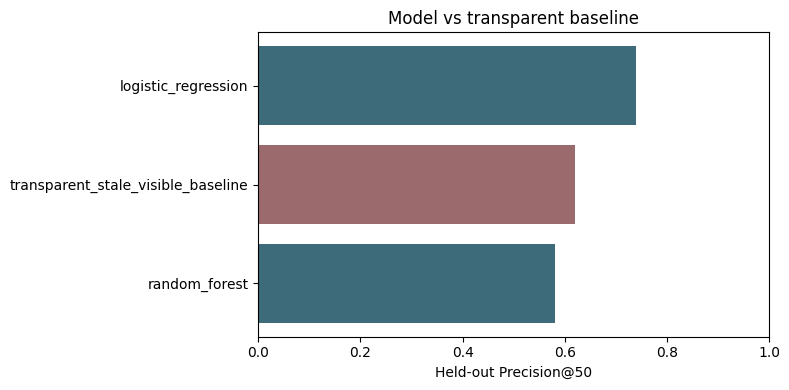

Selected learned model: logistic_regression


In [4]:
display(results.round(3))
results.to_csv(OUT / "capstone_model_vs_baseline.csv", index=False)

chart = results.set_index("model")["precision_at_50"].sort_values()
plt.figure(figsize=(8, 4))
plt.barh(chart.index, chart.values, color=["#9b6a6c" if "baseline" in x else "#3d6b7a" for x in chart.index])
plt.xlim(0, 1); plt.xlabel("Held-out Precision@50"); plt.title("Model vs transparent baseline")
plt.tight_layout(); plt.savefig(FIG / "capstone_precision_at_50.png", dpi=160); plt.show()
print("Selected learned model:", best_name)

## 5. Limitations

*What this work cannot claim.*

This is a trailing-window snapshot, not a prospective experiment. It cannot establish that an edit caused a visibility change, estimate the traffic gain from a refresh, or model Google's ranking algorithm. Results may be influenced by seasonality, measurement differences, and client-specific context not represented in the feature set. The grouped holdout is stronger than a random row split, but a future time-aware holdout would be stronger still.


In [5]:
limitations = pd.DataFrame({"limitation":["No causal refresh effect", "Snapshot rather than future-time test", "Possible seasonality/unobserved context", "Human review remains required"], "implication":["Do not say a refresh will increase traffic", "Do not describe this as future forecasting", "Do not over-interpret feature importance", "Do not automate content changes"]})
print(limitations.to_string(index=False))

                             limitation                                implication
               No causal refresh effect Do not say a refresh will increase traffic
  Snapshot rather than future-time test Do not describe this as future forecasting
Possible seasonality/unobserved context   Do not over-interpret feature importance
          Human review remains required            Do not automate content changes


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final playbook uses the transparent review score and reason codes. A high-ranked page may be tagged as stale and visible, low-CTR and visible, low-engagement and visible, or thin and visible. The intended action is always a manual check: inspect intent, technical status, seasonality, current page quality, and editorial context before selecting a title/meta, content-depth, refresh, or monitoring action.


In [6]:
# Public-safe review queue: no identifiers, URLs, titles, or queries.
visibility = np.log1p(pd.to_numeric(df["impressions_90d"], errors="coerce").fillna(0).clip(lower=0)); visibility /= visibility.max()
stale = (df["days_since_last_update"] >= 180).astype(float)
ctr_opp = ((df["impressions_90d"] >= 500) & df["avg_position"].between(1, 20) & (df["ctr"] < 0.5)).astype(float)
score = 100 * (.55 * visibility + .30 * stale + .15 * ctr_opp)
queue = pd.DataFrame({"review_score":score.round(1), "impressions_90d":df["impressions_90d"], "days_since_last_update":df["days_since_last_update"], "avg_position":df["avg_position"], "ctr":df["ctr"]})
queue["reason_code"] = np.select([ctr_opp.astype(bool), stale.astype(bool)], ["low_ctr_visible_page", "stale_visible_content"], default="monitor_only")
queue["suggested_action"] = np.select([ctr_opp.astype(bool), stale.astype(bool)], ["review_title_meta_and_intent", "manual_refresh_review"], default="monitor")
queue = queue.sort_values("review_score", ascending=False).reset_index(drop=True); queue.insert(0,"rank",queue.index+1)
display(queue.head(20)); queue.head(100).to_csv(OUT / "capstone_ranked_recommendations.csv", index=False)


,rank,review_score,impressions_90d,days_since_last_update,avg_position,ctr,reason_code,suggested_action
0,1,91.1,61678,194,19.7,0.15,low_ctr_visible_page,review_title_meta_and_intent
1,2,84.7,13299,193,10.5,0.49,low_ctr_visible_page,review_title_meta_and_intent
2,3,82.3,7558,193,17.9,0.20,low_ctr_visible_page,review_title_meta_and_intent
3,4,80.2,4556,194,16.4,0.33,low_ctr_visible_page,review_title_meta_and_intent
4,5,76.1,1697,193,15.8,0.12,low_ctr_visible_page,review_title_meta_and_intent
5,6,76.0,59472,194,24.8,0.13,stale_visible_content,manual_refresh_review
6,7,75.3,1408,183,7.8,0.28,low_ctr_visible_page,review_title_meta_and_intent
7,8,73.7,954,301,9.0,0.42,low_ctr_visible_page,review_title_meta_and_intent
8,9,73.1,821,301,5.8,0.24,low_ctr_visible_page,review_title_meta_and_intent
9,10,73.1,828,194,18.6,0.24,low_ctr_visible_page,review_title_meta_and_intent


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper should embed these public-safe artifacts: the model-vs-baseline Precision@50 chart; the data-summary table; the non-leaky client-holdout comparison; a top-20 queue with no identifiers; reason-code definitions; and the limitations section. It should link the repository/notebooks for reproducibility and credit the data source.

**Acknowledgment:** Built on the [FlyRank ML Internship dataset](https://flyrank.ai).


In [7]:
artifact_manifest = pd.DataFrame({"artifact":["Data summary", "Model comparison", "Precision@50 chart", "Ranked recommendations", "Limitations table"], "path":["work/outputs/capstone_data_summary.csv", "work/outputs/capstone_model_vs_baseline.csv", "work/figures/capstone_precision_at_50.png", "work/outputs/capstone_ranked_recommendations.csv", "embedded in notebook"]})
print(artifact_manifest.to_string(index=False)); artifact_manifest.to_csv(OUT / "capstone_artifact_manifest.csv", index=False)

              artifact                                             path
          Data summary           work/outputs/capstone_data_summary.csv
      Model comparison      work/outputs/capstone_model_vs_baseline.csv
    Precision@50 chart        work/figures/capstone_precision_at_50.png
Ranked recommendations work/outputs/capstone_ranked_recommendations.csv
     Limitations table                             embedded in notebook


## ML-12 closing cells

**Five-minute demo outline:** (1) editorial prioritization problem; (2) anonymized data and safety; (3) baseline vs learned models; (4) client-holdout validation and leakage exclusion; (5) reason-coded human review queue and limitations.

**Social-post cut:** I built a leakage-aware content-review prioritization workflow on FlyRank's anonymized internship dataset. It compares a transparent baseline with learned models on held-out clients and creates a reason-coded queue for human review. The findings are directional decision support, not a claim about Google's algorithm or guaranteed traffic growth.

**Employer-facing summary:** I built an end-to-end ML research workflow across 30,000 anonymized content items: data framing, grouped validation, leakage checks, model-vs-baseline evaluation, and a safe action playbook. I focused on reproducible, decision-relevant metrics and honest limits.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
